## Required Libs

In [2]:
import pandas as pd
import numpy as np
import os
import torch

## Read Data

In [ ]:
path = "F://programming//Bootcamp//week28"
df = pd.read_csv(os.path.join(path,"SMSSpamCollection"),sep = "\t", header= None , names=["label","text"])

## Data Preprocessing

In [67]:
df = df.drop_duplicates()

In [ ]:

df["lowercase"] = df["text"].str.lower()
df["tokens"] = df["lowercase"].str.split()
df["label"] = df["label"].map({"ham": 0 , "spam": 1})


## Explicit data to Train/Test

In [ ]:
x = df["tokens"]
y = df["label"]


In [70]:
from sklearn.model_selection import train_test_split

x_train , x_test , y_train , y_test = train_test_split(x, y, test_size=0.2, random_state= 23)


## Vocabulary and token encoding

### Tokens repeat rate

In [71]:
from collections import Counter

counter = Counter()

for tokens in x_train:
    counter.update(tokens)


### Define vocabulary

In [72]:
vocabs = {
    "<PAD>" : 0,
    "<UNK>" : 1,

}

for word , count in counter.items():
    if count >= 2:
        vocabs[word] = len(vocabs)



### Token ecncoding

In [73]:
x_train_encoded = []

for tokens in x_train:
    encoded = []
    for token in tokens:
        if token in vocabs:
            encoded.append(vocabs[token])
        else:
            encoded.append(vocabs["<UNK>"])
    x_train_encoded.append(encoded)

## Padding data

### Find length of largest sample

In [74]:
max_len = 0

for x in x_train_encoded:
    if len(x)>max_len:
        max_len = len(x)



### Padding data

In [75]:
x_train_padded = []

for encoded in x_train_encoded:
    padded = encoded + [0] * (max_len - len(encoded))
    x_train_padded.append(padded)



## Embedding words

In [76]:
x_train_tensor = torch.tensor(x_train_padded)


In [77]:
vocab_size = len(vocabs)
embedding_dim = 100

In [78]:
import torch.nn as nn 

embedding = nn.Embedding(num_embeddings=vocab_size,embedding_dim=embedding_dim,padding_idx=vocabs["<PAD>"])

## Mask padded data

In [79]:
mask = x_train_tensor != 0

In [80]:
mask = mask.unsqueeze(-1)

In [81]:
embedded = embedding(x_train_tensor)

embedded_masked = embedded * mask

## Mean pooling

In [82]:
summed = embedded_masked.sum(dim=1)
count = mask.sum(dim=1)

In [83]:
x_maen = summed / count

## Define linear model by Pytorch

In [84]:
linear = nn.Linear(100,2)
logit = linear(x_maen)


## Train evaluation

In [ ]:
y_train_tensor = torch.tensor(y_train,dtype=torch.long)

In [88]:
loss_fn = nn.CrossEntropyLoss()
loss = loss_fn(logit,y_train_tensor)

In [ ]:
optimizer = torch.optim.Adam(list(embedding.parameters()) + list(linear.parameters()),lr= 0.001)

In [91]:
for epoch in range(100):
    optimizer.zero_grad()

    embedded = embedding(x_train_tensor)
    embedded_masked = embedded * mask
    summed = embedded_masked.sum(dim = 1)
    count = mask.sum(dim= 1)
    x_mean = summed / count

    logit = linear(x_mean)


    loss = loss_fn(logit ,y_train_tensor)

    loss.backward()

    optimizer.step()

    if epoch % 10 == 0 :
        print(epoch , loss.item())



0 0.27424129843711853
10 0.24920625984668732
20 0.22550521790981293
30 0.20327456295490265
40 0.1827126443386078
50 0.16398608684539795
60 0.14717420935630798
70 0.13225512206554413
80 0.11912386864423752
90 0.10762374103069305


In [92]:
y_train_pred = logit.argmax(dim=1)

In [94]:
y_train_pred_np = y_train_pred.numpy()

## Report train evaluation result

In [95]:
from sklearn.metrics import classification_report
report = classification_report(y_train,y_train_pred_np)
print(report)

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3606
           1       0.99      0.83      0.90       529

    accuracy                           0.98      4135
   macro avg       0.98      0.92      0.94      4135
weighted avg       0.98      0.98      0.98      4135



## Test data encoding

In [96]:
x_test_encoded = []

for tokens in x_test:
    encoded = []
    for token in tokens:
        if token in vocabs:
            encoded.append(vocabs[token])
        else:
            encoded.append(vocabs["<UNK>"])
    x_test_encoded.append(encoded)


## Test data padding

In [97]:
x_test_padded = []

for encoded in x_test_encoded:
    encoded = encoded[:max_len]
    padded = encoded + [0] * (max_len - len(encoded))
    x_test_padded.append(padded)


## Test data masking, embedding, mean pooling 

In [98]:
x_test_tensor = torch.tensor(x_test_padded)

In [99]:
mask_test = x_test_tensor != 0
mask_test = mask_test.unsqueeze(-1)

with torch.no_grad():
    embedded_test = embedding(x_test_tensor)
    embedded_masked_test = embedded_test * mask_test

    summed_test = embedded_masked_test.sum(dim= 1)
    count_test = mask_test.sum(dim= 1)

    x_test_mean = summed_test / count_test



## Predict classification on test data

In [100]:
with torch.no_grad():
    logit_test = linear(x_test_mean)


In [102]:
y_test_pred = logit_test.argmax(dim=1)

## Report evaluation result

In [103]:
y_test_pred_np = y_test_pred.numpy()

print(classification_report(y_test,y_test_pred_np))

              precision    recall  f1-score   support

           0       0.95      1.00      0.97       910
           1       0.95      0.60      0.73       124

    accuracy                           0.95      1034
   macro avg       0.95      0.80      0.85      1034
weighted avg       0.95      0.95      0.94      1034



## Visualize model prediction result

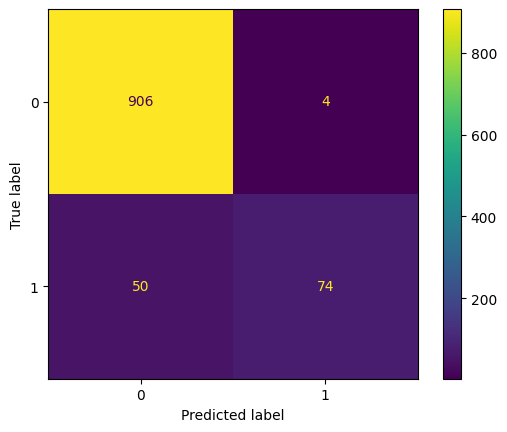

In [105]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test,y_test_pred_np)
plt.show()